## vzani/corpus-fake-br

Fake.br: 7.200 noticias em portugues, balanceadas entre verdadeiras e falsas (3.600 de cada),
ja divididas em treino (5.760) e teste (1.440).

Colunas: `text`, `label` (bool: `True` = noticia verdadeira, `False` = fake), `corpus`,
e versoes truncadas do texto (`truncated_simple`, `truncated_lstm`, `truncated_bert`).

In [46]:
import pandas as pd

base = "hf://datasets/vzani/corpus-fake-br/"

# engine="fastparquet": o pyarrow 19.0.0 falha nesses arquivos
# ("Repetition level histogram size mismatch")
df_train_fake = pd.read_parquet(base + "corpus_train_df.parquet", engine="fastparquet")
df_test_fake = pd.read_parquet(base + "corpus_test_df.parquet", engine="fastparquet")

# 1 = verdadeira, 0 = fake
df_train_fake['label'] = df_train_fake['label'].astype(int)
df_test_fake['label'] = df_test_fake['label'].astype(int)

print(df_train_fake.shape, df_test_fake.shape)
df_train_fake.head()

(5760, 6) (1440, 6)


,text,label,corpus,truncated_simple,truncated_lstm,truncated_bert
1329,Reunião urgente do Foro de SP ? Dilma chega à ...,0,Fake.br,Reunião urgente do Foro de SP ? Dilma chega à ...,Reunião urgente do Foro de SP ? Dilma chega à ...,Reunião urgente do Foro de SP ? Dilma chega à ...
6964,Cláudia Trevisan ENVIADA ESPECIAL / NOVA YORK...,1,Fake.br,Cláudia Trevisan ENVIADA ESPECIAL / NOVA YOR...,Cláudia Trevisan ENVIADA ESPECIAL / NOVA YOR...,Cláudia Trevisan ENVIADA ESPECIAL / NOVA YO...
2315,"Dilma faz a turma da mortadela delirar: ""Eu so...",0,Fake.br,"Dilma faz a turma da mortadela delirar: "" Eu s...","Dilma faz a turma da mortadela delirar: "" Eu s...","Dilma faz a turma da mortadela delirar: "" Eu s..."
3884,O depoimento de Luiz Inácio Lula da Silva ao ...,1,Fake.br,O depoimento de Luiz Inácio Lula da Silva ao...,O depoimento de Luiz Inácio Lula da Silva ao...,O depoimento de Luiz Inácio Lula da Silva a...
654,Conheça os candidatos declarados à presidência...,1,Fake.br,Conheça os candidatos declarados à presidência...,Conheça os candidatos declarados à presidência...,Conheça os candidatos declarados à presidência...


In [47]:
print(df_train_fake['label'].value_counts(dropna=False))
print()
print(df_test_fake['label'].value_counts(dropna=False))

label
0    2880
1    2880
Name: count, dtype: int64

label
0    720
1    720
Name: count, dtype: int64


In [52]:
df_train_fake = df_train_fake[["text","label"]]
df_test_fake = df_test_fake[["text","label"]]

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Create a pipeline with TfidfVectorizer and LogisticRegression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])
pipeline.fit(df_train_fake['text'], df_train_fake['label'])
y_pred = pipeline.predict(df_test_fake['text'])
report = classification_report(df_test_fake['label'], y_pred)
print(report)
pesos = pd.Series(pipeline.named_steps['clf'].coef_[0], index=pipeline.named_steps['tfidf'].get_feature_names_out()).sort_values()
print(pesos)  # menores = puxam para fake (0), maiores = puxam para verdadeira (1)


              precision    recall  f1-score   support

           0       0.94      0.96      0.95       720
           1       0.96      0.94      0.95       720

    accuracy                           0.95      1440
   macro avg       0.95      0.95      0.95      1440
weighted avg       0.95      0.95      0.95      1440

dilma    -3.018305
coréia   -2.695234
lula     -2.461589
moro     -1.386753
cunha    -1.228054
            ...   
da        4.981270
do        5.175196
que       5.352422
em        5.389407
de        8.707876
Length: 77670, dtype: float64


## HenriqueLz/fakerecogna2-extrativa-elections

FakeRecogna 2.0 (extrativa) com split **temporal** em 30/10/2021: treino com noticias ate essa data
(42.031) e teste com o periodo eleitoral de 2022-2023 (10.504). Feito para avaliar concept drift,
entao o teste e desbalanceado (majoritariamente fake).

Colunas originais: `date`, `labels` (0 = verdadeira, 1 = fake), `text`.
Abaixo o rotulo e invertido para seguir a mesma convencao do resto do notebook (1 = verdadeira).

In [54]:
base_recogna = "hf://datasets/HenriqueLz/fakerecogna2-extrativa-elections/"

df_train_recogna = pd.read_parquet(base_recogna + "data/train-00000-of-00001.parquet", engine="fastparquet")
df_test_recogna = pd.read_parquet(base_recogna + "data/test-00000-of-00001.parquet", engine="fastparquet")

# original: 0 = verdadeira, 1 = fake -> aqui: 1 = verdadeira, 0 = fake
df_train_recogna = df_train_recogna.rename(columns={'labels': 'label'})
df_test_recogna = df_test_recogna.rename(columns={'labels': 'label'})
df_train_recogna['label'] = 1 - df_train_recogna['label']
df_test_recogna['label'] = 1 - df_test_recogna['label']

print(df_train_recogna.shape, df_test_recogna.shape)
df_train_recogna.head()

(42031, 3) (10504, 3)


,date,label,text
0,2018-09-14,0,O Padre Marcelo Rossi gravou áudio pedindo vot...
1,2021-10-18,1,Rondônia recebe a Oficina Previne Brasil nesta...
2,2020-11-29,0,\nVídeo não mostra urna adulterada dentro de c...
3,2018-08-30,0,Áudio em que mulher grita 'eu voto Lula' em ví...
4,2020-05-04,0,É falso que dados de cartórios ‘comprovam’ que...


In [55]:
print(df_train_recogna['label'].value_counts())
print()
print(df_test_recogna['label'].value_counts())

label
1    23862
0    18169
Name: count, dtype: int64

label
0    8178
1    2326
Name: count, dtype: int64


In [56]:
df_train_recogna = df_train_recogna[["text","label"]]
df_test_recogna = df_test_recogna[["text","label"]]

In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Create a pipeline with TfidfVectorizer and LogisticRegression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])
pipeline.fit(df_train_recogna['text'], df_train_recogna['label'])
y_pred = pipeline.predict(df_test_recogna['text'])
report = classification_report(df_test_recogna['label'], y_pred)
print(report)
pesos = pd.Series(pipeline.named_steps['clf'].coef_[0], index=pipeline.named_steps['tfidf'].get_feature_names_out()).sort_values()
print(pesos)  # menores = puxam para fake (0), maiores = puxam para verdadeira (1)


              precision    recall  f1-score   support

           0       0.99      0.93      0.96      8178
           1       0.80      0.96      0.87      2326

    accuracy                           0.94     10504
   macro avg       0.89      0.95      0.92     10504
weighted avg       0.95      0.94      0.94     10504

boato     -26.353661
falso     -10.190271
verdade    -9.917028
circula    -7.923140
erra       -7.396244
             ...    
afirmou     6.180522
nesta       6.885816
disse       7.244662
hoje        7.553397
feira       7.563770
Length: 81214, dtype: float64


## vzani/corpus-faketrue-br

FakeTrue.Br: 3.582 textos em portugues, balanceados (1.791 pares), divididos em treino (2.865) e
teste (717). Mesmo formato do `corpus-fake-br`: `text`, `label` (`True` = verdadeira, `False` = fake),
`corpus` e as versoes truncadas.

In [58]:
base_faketrue = "hf://datasets/vzani/corpus-faketrue-br/"

df_train_faketrue = pd.read_parquet(base_faketrue + "corpus_train_df.parquet", engine="fastparquet")
df_test_faketrue = pd.read_parquet(base_faketrue + "corpus_test_df.parquet", engine="fastparquet")

# 1 = verdadeira, 0 = fake
df_train_faketrue['label'] = df_train_faketrue['label'].astype(int)
df_test_faketrue['label'] = df_test_faketrue['label'].astype(int)

print(df_train_faketrue.shape, df_test_faketrue.shape)
df_train_faketrue.head()

(2865, 6) (717, 6)


,text,label,corpus,truncated_simple,truncated_lstm,truncated_bert
822,circula nas redes sociais um vídeo que mostra...,1,FakeTrue.Br,circula nas redes sociais um vídeo que mostr...,circula nas redes sociais um vídeo que mostr...,circula nas redes sociais um vídeo que most...
2966,circula nas redes sociais uma foto da diretor...,1,FakeTrue.Br,circula nas redes sociais uma foto da direto...,circula nas redes sociais uma foto da direto...,circula nas redes sociais uma foto da diret...
2567,o pai do juiz se dizia apolitico. ele viveu os...,0,FakeTrue.Br,o pai do juiz se dizia apolitico. ele viveu os...,o pai do juiz se dizia apolitico. ele viveu os...,o pai do juiz se dizia apolitico. ele viveu os...
2922,circula nas redes sociais que o governo do pe...,1,FakeTrue.Br,circula nas redes sociais que o governo do p...,circula nas redes sociais que o governo do p...,circula nas redes sociais que o governo do ...
3329,"anteriormente, o dietary guidelines for ameri...",0,FakeTrue.Br,"anteriormente, o dietary guidelines for amer...","anteriormente, o dietary guidelines for amer...","anteriormente, o dietary guidelines for ame..."


In [59]:
print(df_train_faketrue['label'].value_counts())
print()
print(df_test_faketrue['label'].value_counts())

label
1    1433
0    1432
Name: count, dtype: int64

label
0    359
1    358
Name: count, dtype: int64


In [60]:
df_train_faketrue = df_train_faketrue[["text","label"]]
df_test_faketrue = df_test_faketrue[["text","label"]]

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# Create a pipeline with TfidfVectorizer and LogisticRegression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])
pipeline.fit(df_train_faketrue['text'], df_train_faketrue['label'])
y_pred = pipeline.predict(df_test_faketrue['text'])
report = classification_report(df_test_faketrue['label'], y_pred)
print(report)
pesos = pd.Series(pipeline.named_steps['clf'].coef_[0], index=pipeline.named_steps['tfidf'].get_feature_names_out()).sort_values()
print(pesos)  # menores = puxam para fake (0), maiores = puxam para verdadeira (1)


              precision    recall  f1-score   support

           0       0.96      0.98      0.97       359
           1       0.98      0.96      0.97       358

    accuracy                           0.97       717
   macro avg       0.97      0.97      0.97       717
weighted avg       0.97      0.97      0.97       717

nao    -2.721633
voce   -1.470370
esta   -1.423754
span   -1.306999
org    -1.127532
          ...   
da      3.718216
em      4.526506
lupa    4.558407
que     5.057033
de      6.648574
Length: 38644, dtype: float64


# Cross faketrue e fake

In [62]:

# Create a pipeline with TfidfVectorizer and LogisticRegression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])
pipeline.fit(df_train_faketrue['text'], df_train_faketrue['label'])
y_pred = pipeline.predict(df_test_fake['text'])
report_faketrue_fake = classification_report(df_test_fake['label'], y_pred)
print(report_faketrue_fake)
pesos = pd.Series(pipeline.named_steps['clf'].coef_[0], index=pipeline.named_steps['tfidf'].get_feature_names_out()).sort_values()
print(pesos)  # menores = puxam para fake (0), maiores = puxam para verdadeira (1)


              precision    recall  f1-score   support

           0       0.97      0.76      0.85       720
           1       0.80      0.98      0.88       720

    accuracy                           0.87      1440
   macro avg       0.89      0.87      0.87      1440
weighted avg       0.89      0.87      0.87      1440

nao    -2.721633
voce   -1.470370
esta   -1.423754
span   -1.306999
org    -1.127532
          ...   
da      3.718216
em      4.526506
lupa    4.558407
que     5.057033
de      6.648574
Length: 38644, dtype: float64


In [63]:


# Create a pipeline with TfidfVectorizer and LogisticRegression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])
pipeline.fit(df_train_fake['text'], df_train_fake['label'])
y_pred = pipeline.predict(df_test_faketrue['text'])
report_fake_faketrue = classification_report(df_test_faketrue['label'], y_pred)
print(report_fake_faketrue)
pesos = pd.Series(pipeline.named_steps['clf'].coef_[0], index=pipeline.named_steps['tfidf'].get_feature_names_out()).sort_values()
print(pesos)  # menores = puxam para fake (0), maiores = puxam para verdadeira (1)


              precision    recall  f1-score   support

           0       0.66      0.99      0.79       359
           1       0.98      0.49      0.66       358

    accuracy                           0.74       717
   macro avg       0.82      0.74      0.72       717
weighted avg       0.82      0.74      0.72       717

dilma    -3.018305
coréia   -2.695234
lula     -2.461589
moro     -1.386753
cunha    -1.228054
            ...   
da        4.981270
do        5.175196
que       5.352422
em        5.389407
de        8.707876
Length: 77670, dtype: float64


# Cross fake e recogna

In [64]:

# Create a pipeline with TfidfVectorizer and LogisticRegression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])
pipeline.fit(df_train_recogna['text'], df_train_recogna['label'])
y_pred = pipeline.predict(df_test_fake['text'])
report_recogna_fake = classification_report(df_test_fake['label'], y_pred)
print(report_recogna_fake)
pesos = pd.Series(pipeline.named_steps['clf'].coef_[0], index=pipeline.named_steps['tfidf'].get_feature_names_out()).sort_values()
print(pesos)  # menores = puxam para fake (0), maiores = puxam para verdadeira (1)


              precision    recall  f1-score   support

           0       0.99      0.26      0.41       720
           1       0.57      1.00      0.73       720

    accuracy                           0.63      1440
   macro avg       0.78      0.63      0.57      1440
weighted avg       0.78      0.63      0.57      1440

boato     -26.353661
falso     -10.190271
verdade    -9.917028
circula    -7.923140
erra       -7.396244
             ...    
afirmou     6.180522
nesta       6.885816
disse       7.244662
hoje        7.553397
feira       7.563770
Length: 81214, dtype: float64


In [65]:

# Create a pipeline with TfidfVectorizer and LogisticRegression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])
pipeline.fit(df_train_fake['text'], df_train_fake['label'])
y_pred = pipeline.predict(df_test_recogna['text'])
report_fake_recogna = classification_report(df_test_recogna['label'], y_pred)
print(report_fake_recogna)
pesos = pd.Series(pipeline.named_steps['clf'].coef_[0], index=pipeline.named_steps['tfidf'].get_feature_names_out()).sort_values()
print(pesos)  # menores = puxam para fake (0), maiores = puxam para verdadeira (1)


              precision    recall  f1-score   support

           0       0.78      0.99      0.87      8178
           1       0.45      0.02      0.04      2326

    accuracy                           0.78     10504
   macro avg       0.62      0.51      0.46     10504
weighted avg       0.71      0.78      0.69     10504

dilma    -3.018305
coréia   -2.695234
lula     -2.461589
moro     -1.386753
cunha    -1.228054
            ...   
da        4.981270
do        5.175196
que       5.352422
em        5.389407
de        8.707876
Length: 77670, dtype: float64


# Cross faketrue e recogna

In [66]:

# Create a pipeline with TfidfVectorizer and LogisticRegression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])
pipeline.fit(df_train_recogna['text'], df_train_recogna['label'])
y_pred = pipeline.predict(df_test_faketrue['text'])
report_recogna_faketrue = classification_report(df_test_faketrue['label'], y_pred)
print(report_recogna_faketrue)
pesos = pd.Series(pipeline.named_steps['clf'].coef_[0], index=pipeline.named_steps['tfidf'].get_feature_names_out()).sort_values()
print(pesos)  # menores = puxam para fake (0), maiores = puxam para verdadeira (1)


              precision    recall  f1-score   support

           0       0.65      0.71      0.68       359
           1       0.68      0.62      0.65       358

    accuracy                           0.67       717
   macro avg       0.67      0.67      0.67       717
weighted avg       0.67      0.67      0.67       717

boato     -26.353661
falso     -10.190271
verdade    -9.917028
circula    -7.923140
erra       -7.396244
             ...    
afirmou     6.180522
nesta       6.885816
disse       7.244662
hoje        7.553397
feira       7.563770
Length: 81214, dtype: float64


In [67]:

# Create a pipeline with TfidfVectorizer and LogisticRegression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression())
])
pipeline.fit(df_train_faketrue['text'], df_train_faketrue['label'])
y_pred = pipeline.predict(df_test_recogna['text'])
report_faketrue_recogna = classification_report(df_test_recogna['label'], y_pred)
print(report_faketrue_recogna)
pesos = pd.Series(pipeline.named_steps['clf'].coef_[0], index=pipeline.named_steps['tfidf'].get_feature_names_out()).sort_values()
print(pesos)  # menores = puxam para fake (0), maiores = puxam para verdadeira (1)


              precision    recall  f1-score   support

           0       0.77      0.64      0.70      8178
           1       0.20      0.32      0.25      2326

    accuracy                           0.57     10504
   macro avg       0.49      0.48      0.47     10504
weighted avg       0.64      0.57      0.60     10504

nao    -2.721633
voce   -1.470370
esta   -1.423754
span   -1.306999
org    -1.127532
          ...   
da      3.718216
em      4.526506
lupa    4.558407
que     5.057033
de      6.648574
Length: 38644, dtype: float64


# Comparacao: treino x teste

Junta os 3 modelos individuais e as 6 avaliacoes cruzadas numa matriz de acuracia.

In [68]:
datasets_train = {
    'fake': df_train_fake,
    'faketrue': df_train_faketrue,
    'recogna': df_train_recogna
}

datasets_tests = {
    'fake': df_test_fake,
    'faketrue': df_test_faketrue,
    'recogna': df_test_recogna
}

acuracias = {}

for train_name, train_df in datasets_train.items():
    pipeline.fit(train_df['text'], train_df['label'])
    acuracias[train_name] = {}
    for test_name, test_df in datasets_tests.items():
        y_pred = pipeline.predict(test_df['text'])
        report = classification_report(test_df['label'], y_pred, output_dict=True)
        acuracias[train_name][test_name] = report['accuracy']

pd.DataFrame(acuracias).T.round(3)

,fake,faketrue,recogna
fake,0.951,0.742,0.777
faketrue,0.867,0.972,0.570
recogna,0.629,0.667,0.938


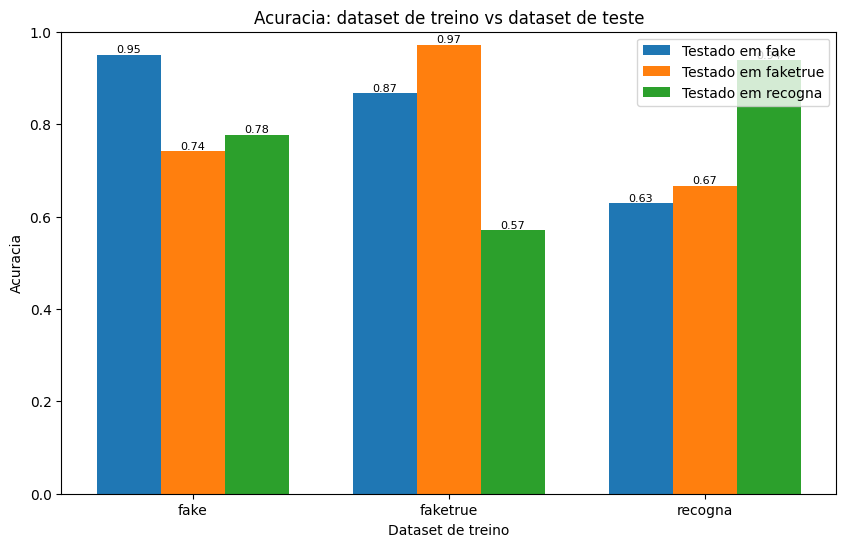

In [69]:
import matplotlib.pyplot as plt
import numpy as np

train_datasets = list(acuracias.keys())
test_datasets = list(acuracias[train_datasets[0]].keys())

x = np.arange(len(train_datasets))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, test_name in enumerate(test_datasets):
    valores = [acuracias[train_name][test_name] for train_name in train_datasets]
    barras = ax.bar(x + i * width, valores, width, label=f'Testado em {test_name}')
    ax.bar_label(barras, fmt='%.2f', fontsize=8)

ax.set_xlabel('Dataset de treino')
ax.set_ylabel('Acuracia')
ax.set_title('Acuracia: dataset de treino vs dataset de teste')
ax.set_xticks(x + width)
ax.set_xticklabels(train_datasets)
ax.set_ylim(0, 1)
ax.legend()
plt.show()